# Unit I: Climate Change Module

## Reproducing the hockey stick, and checking whether we got it right

Our target is the result reported by [Mann et al (1998)](https://doi.org/10.1038/33859): that
recent warming stands outside the range of natural variability over the past several centuries.
You will rebuild that picture from current observations and ice-core records, in the style of
NASA's [vital signs](https://climate.nasa.gov/vital-signs).

A language model will write most of the parsing code. It is good at it, and it is also wrong in
ways that run cleanly and produce a plot. Your job is the question scientists have always had to
answer about code they did not write:

> **How do I know these numbers are right?**

Each part below gives you a data source and a question. It does not tell you what is wrong with
the data. Finding that out is the assignment.

## Rules of engagement

- **Plan mode only.** You review and approve the plan before any code runs.
- **Keep your prompts.** Record what you asked for. The prompt is part of your method.
- **Never report a number you have not checked.** Unverified or fabricated data is the one
  automatic-failure condition in this module, and it is no less serious because a model produced
  it.

Setup, GitHub authentication, and model configuration are on the
[course website](https://espm-157.carlboettiger.info/).

### Verification block

Every dataset gets these five questions answered, in your own words, **before** you plot it.
Each part below ends with one.

1. **Extent** — how many rows, what time range, and does that match the source documentation?
2. **Missing data** — how is it encoded, and did your parser catch it?
3. **Units** — what are they, and where in the source is that stated?
4. **Completeness** — the whole dataset, or one piece of it?
5. **Cross-check** — one value confirmed against an independent source.

---

# Part 1: The code you didn't write

Mauna Loa monthly CO2: <https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt>

Below is working code for that file. It runs and it produces a plausible plot.

In [1]:
import pandas as pd
from plotnine import *

In [2]:
columns = ['year', 'month', 'decimal_date', 'average', 'smooth', 'std_days', 'uncertainty', 'empty']
df = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt",
                  sep = '\\s+',
                  comment = '#',
                  header = None,
                  names = columns
                  )
df

,year,month,decimal_date,average,smooth,std_days,uncertainty,empty
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26


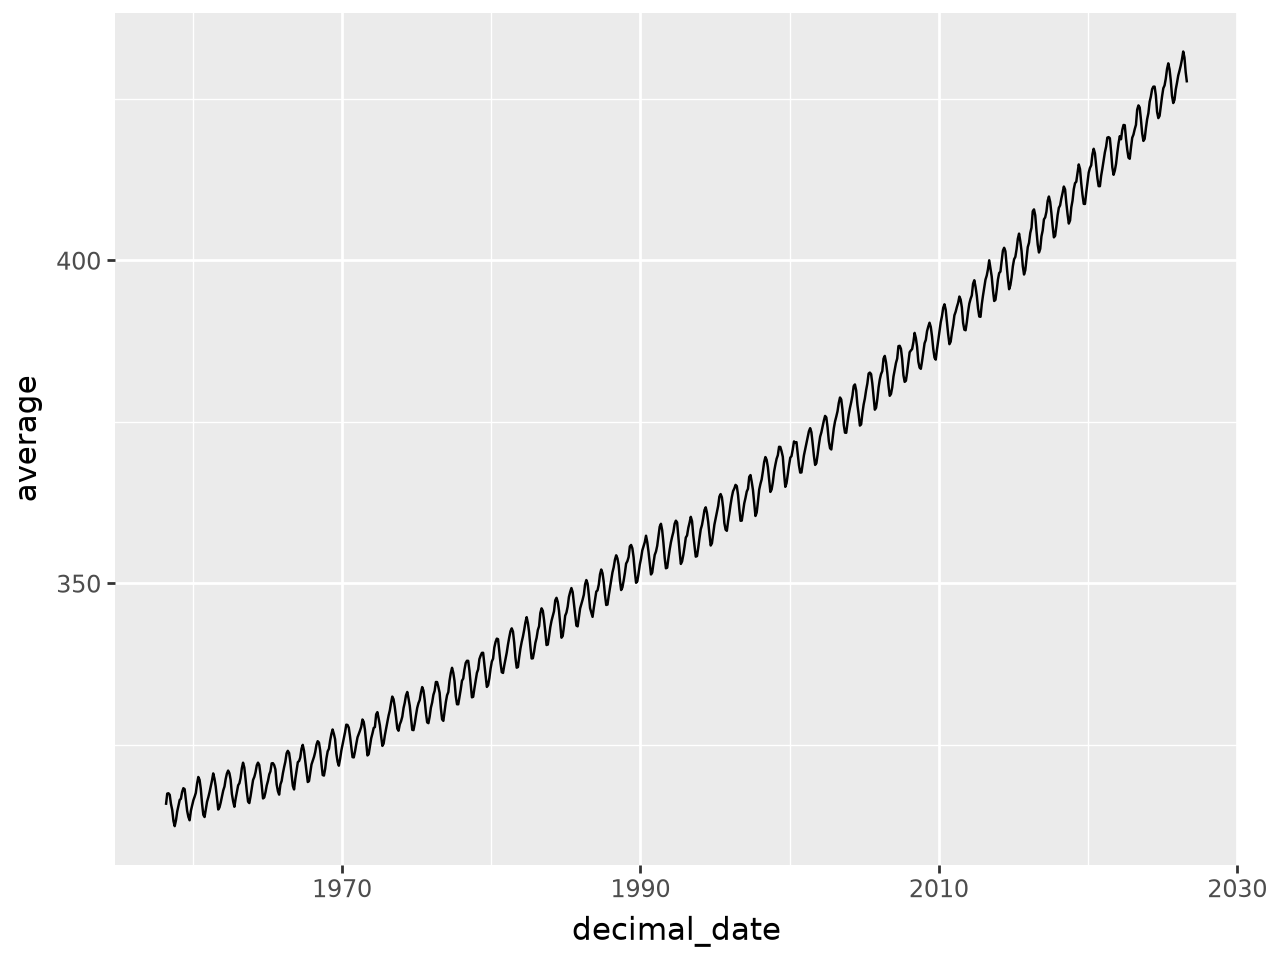

In [3]:
ggplot(df, aes(x="decimal_date", y="average")) + geom_line()

### Task 1.1: Read the source, not the code

That `columns` list was written by hand. Open the raw file and read its header block, then check
every name against what the header says the column holds. Report any that misstate it, and say
which of those would change a published figure if nobody noticed. 

**Your answer:** The "#days" column in the raw file, as well as the deseasonalized, the standard deviation of days, and uncertainty of monthly mean columns are mislabeled in our table. None of these would affect our figure as it used the decimal date and monthly average to construct itself.  

### Task 1.2: Missing values

How does this file encode a measurement that was not made? Verify it in the raw file, count the
affected rows per column, and say what a naive `mean()`, `min()`, or error bar would report if you
left them in. State what you did about it and why.

In [4]:
missing_months = df["uncertainty"] == -9.99
print(missing_months.sum())  
df[missing_months]     

196


,year,month,decimal_date,average,smooth,std_days,uncertainty,empty
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
191,1974,2,1974.1260,330.71,330.03,-1,-9.99,-0.99
192,1974,3,1974.2027,331.49,330.15,-1,-9.99,-0.99
193,1974,4,1974.2877,332.65,330.24,-1,-9.99,-0.99
213,1975,12,1975.9583,330.77,331.74,-1,-9.99,0.00


**Your answer:** The file encodes measurements that were not made by representing them with negative numbers. These numbers stand in for "blank data." The average is significantly influenced  by these measurements. To prevent these measurements from influencing our averages, we could omit these missing measuerements from our table entirely.

### Task 1.3: What the numeric columns cannot tell you

The header block contains prose notes as well as column definitions. Read them.

Does anything there change how you would plot or interpret this series? Show your evidence in the
data rather than asserting it, and say whether a model reading only the numeric columns would have
any way to know.

In [5]:
subset = df[(df["year"] >= 1973) & (df["year"] <= 1976)]

naive_unc = subset["uncertainty"].mean()                          # includes -0.99 / 0.00 flags
real_unc = subset.loc[subset["uncertainty"] > 0, "uncertainty"].mean()  # flags removed

print(f"Mean monthly average 1973-1976 : {subset['average'].mean():.2f} ppm")
print(f"Naive mean uncertainty         : {naive_unc:.2f}")
print(f"Mean uncertainty (flags removed): {real_unc:.2f}")
print(f"Months used for 'real' mean    : {(subset['uncertainty'] > 0).sum()} of {len(subset)}")

Mean monthly average 1973-1976 : 330.76 ppm
Naive mean uncertainty         : -3.27
Mean uncertainty (flags removed): 0.41
Months used for 'real' mean    : 31 of 48


**Your answer:** From our human perspectives, we can learn to ignore the negative values as we understand they don't really represent anyhting, especially if the monthly averages for those months are still recorded. However, computers have a harder time distinguishing things. We can see here that the average uncertainty from 1973 to 1976 would be -3.27 if the negative uncertainty values were incorporated into the calculations, which would mean nothing to us. However, we can specify with our agent to disregard thenegative values, giving us a "real" mean uncertainty of 0.41.

Monthly averages are also determined by the average of daily CO2 values measured in a given month. Some months have almost 30 days, while some have under 10. Therefore, when plotting, a model wouldn't be able to take that information into account when constructing a plot of monthly CO2 averages. This would be more clearly expressed if we had access to the exact days these CO2 measurements were taken, giving us a more accurate idea of CO2 values.

### Task 1.4: Check whether a better door exists

Before you fix a parser, find out whether you need one. NOAA distributes this same monthly record
in more than one format: <https://gml.noaa.gov/ccgg/trends/data.html>

Load an alternative distribution. Which of the problems you found above does switching formats
solve, and which does it not?

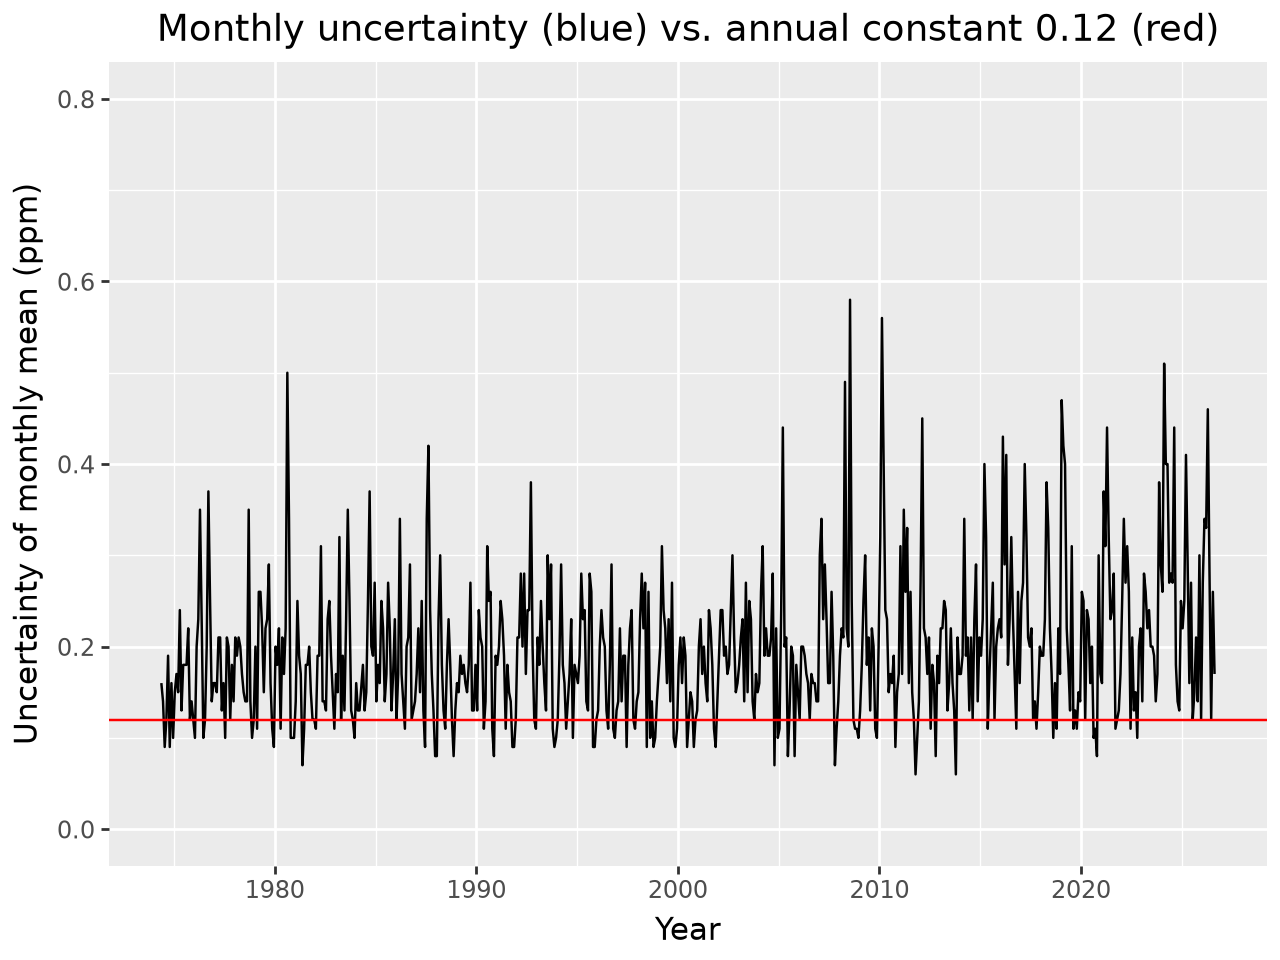

In [6]:
annual = pd.read_csv(
    "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_annmean_mlo.txt",
    sep=r"\s+",
    comment="#",
    header=None,
    names=["year", "mean", "unc"],
)

annual
annual["unc"].value_counts()
monthly = pd.read_csv(
    "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv",
    comment="#",
)

monthly
flagged = monthly["unc"] < 0

flagged.sum()

monthly_valid = monthly.loc[monthly["unc"] > 0].rename(columns={"decimal date": "date"})

(ggplot(monthly_valid, aes(x="date", y="unc"))
 + geom_line()
 + ylim(0, 0.8)
 + geom_hline(yintercept=0.12, color="red")
 + labs(x="Year", y="Uncertainty of monthly mean (ppm)",
        title="Monthly uncertainty (blue) vs. annual constant 0.12 (red)"))


**Your answer:** While the annual mean data effectively disregards the uncertainty by standardizing the uncertainty to 0.12 throughout the data, it essentially makes the uncertainty value within that data useless. In the monthly mean data, we have a much clearer view of what the uncertainty is per month, but it can still be influenced by the missing month uncertainty values of -0.99.

### Task 1.5: The other library

Now try to load the original `.txt` with `ibis` instead of `pandas`. Report what happens.

Explain the result in terms of the *file*, not the library. What does it do to a rule like "always
use `ibis`"?

In [7]:
import ibis

t = ibis.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt")

**Your answer:** ibis expects data that has already been organized into a table. It doesn't work well when attempting to analyze a raw text file. "Always use ibis" only works when the data is already a table. Here, we want to organize a table, so ibis is useless.

In [8]:
mauna_loa_2024 = df.loc[(df["year"] == 2024) & (df["average"] > 0), "average"].mean()

mauna_loa_2024.round(2)

np.float64(424.6)

### 🔍 Verification block 1

1. Extent: The Mauna Loa data was sampled from 1958 to 2026.
2. Missing data: Missing data was represeneted with negative values.
3. Units: The main unit being used in this data is ppmv, as a way to quantify the amount of CO2 present in the atmosphere near Mauna Loa.
4. Completeness: Missing values were handlesd by not being directly incorporated into calculations regarding standard deviation and uncertainty, instead being left out. However, we did also do calculations involving the " naive" values (the original negative placeholders. for missing data) to see how unknowingly including them incalculations could affect final values.
5. Cross-check: Above,  we used the year 2024 as a means to make sure our values were in line. NOAA's official 2024 average ppmv at Mauna Loa was 424.61, and our calculated mean for 2024 was 424.6.

---

# Part 2: Arctic sea ice

National Snow and Ice Data Center, sea ice index G02135:

- Documentation: <https://nsidc.org/data/G02135>
- Data directory: <https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/>

### Task 2.1: Ask first, look second

Before opening that directory yourself, ask your model to load Arctic sea ice extent and plot the
trend. Let it produce a plan.

**Record the prompt you used:**

```
Load the Arctic sea ice extent from this data, then plot it: https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/
```

    year  mo source_dataset region  extent   area       date
0   1978  11     NSIDC-0051      N   11.65   9.04 1978-11-01
1   1978  12     NSIDC-0051      N   13.67  10.90 1978-12-01
2   1979   1     NSIDC-0051      N   15.41  12.41 1979-01-01
3   1979   2     NSIDC-0051      N   16.18  13.18 1979-02-01
4   1979   3     NSIDC-0051      N   16.34  13.21 1979-03-01
5   1979   4     NSIDC-0051      N   15.45  12.53 1979-04-01
6   1979   5     NSIDC-0051      N   13.86  11.11 1979-05-01
7   1979   6     NSIDC-0051      N   12.53   9.34 1979-06-01
8   1979   7     NSIDC-0051      N   10.31   6.69 1979-07-01
9   1979   8     NSIDC-0051      N    8.04   5.06 1979-08-01
10  1979   9     NSIDC-0051      N    7.05   4.58 1979-09-01
11  1979  10     NSIDC-0051      N    8.75   6.19 1979-10-01
12  1979  11     NSIDC-0051      N   10.94   8.37 1979-11-01
13  1979  12     NSIDC-0051      N   13.34  10.63 1979-12-01
14  1980   1     NSIDC-0051      N   14.86  11.94 1980-01-01
15  1980   2     NSIDC-0

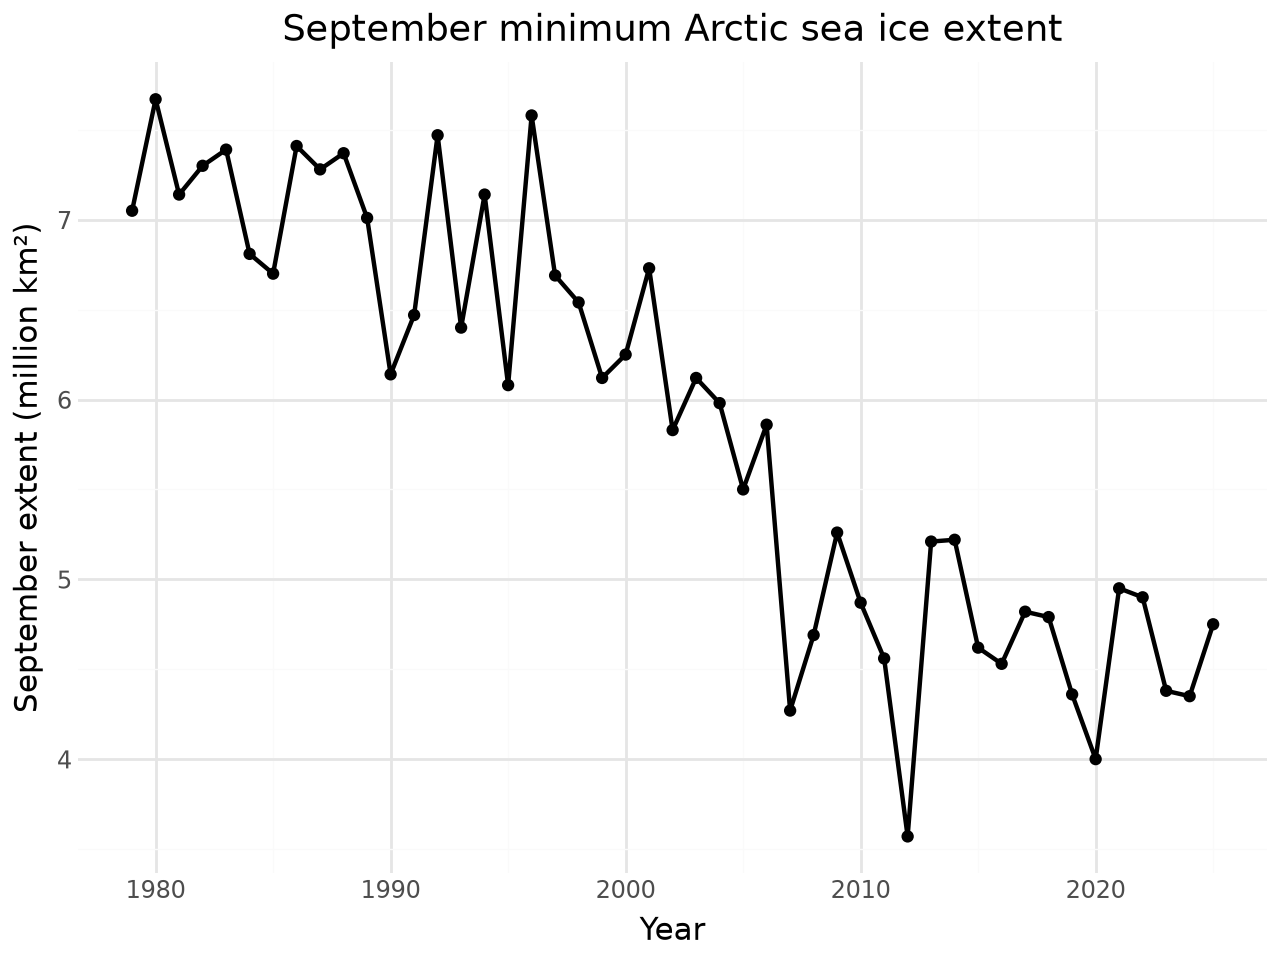

In [9]:
import pandas as pd
from plotnine import *

base = "https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/"

frames = []
for m in range(1, 13):
    url = f"{base}N_{m:02d}_extent_v4.0.csv"
    d = pd.read_csv(url, skipinitialspace=True)
    frames.append(d)

seaice = pd.concat(frames, ignore_index=True)

# Build a proper date index and sort chronologically
seaice["date"] = pd.to_datetime({"year": seaice["year"],
                                 "month": seaice["mo"],
                                 "day": 1})
seaice = seaice.sort_values("date").reset_index(drop=True)
print(seaice.head(20))
print("rows:", len(seaice), "| years:", seaice["year"].min(), "-", seaice["year"].max())

(ggplot(seaice, aes(x="date", y="extent", color="mo"))
 + geom_point(size=1.2, alpha=0.6)
 + labs(x="Date", y="Sea ice extent (million km²)",
        title="Arctic sea ice extent, monthly (G02135, north)")
 + theme_minimal())

(ggplot(seaice[seaice["mo"] == 9], aes(x="year", y="extent"))
 + geom_line(size=0.9)
 + geom_point(size=1.5)
 + labs(x="Year", y="September extent (million km²)",
        title="September minimum Arctic sea ice extent")
 + theme_minimal())

### Task 2.2: What did it actually load?

Now open the data directory and look at what is there.

Check the URL the model's code used against the directory listing *before* you run anything. Did
it point at a file that exists? If it ran, how much of the record does the plot actually show, and
is the title honest? If it failed, would you have predicted that failure from reading the code?

A model that has never seen this directory still has to produce a filename. Note where it got one.

**Your answer:** It did point at a file that exists and used September's monthly data to build a plot. It shows the entire record of Septmber's monthly ice extent values from 1979 to 2025.

### Task 2.3: Build the complete record

Load the full dataset and plot sea ice extent over time.

Then make a scientific decision and defend it: the September minimum is the standard index for
Arctic sea ice loss, and it is not the same thing as the annual mean. Which does your analysis
report, and why is that right for the question you are asking?

In [10]:
base = "https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/"

seaice = pd.concat(
    [pd.read_csv(f"{base}N_{m:02d}_extent_v4.0.csv", skipinitialspace=True) for m in range(1, 13)],
    ignore_index=True,
)

seaice["date"] = pd.to_datetime(
    seaice.rename(columns={"mo": "month"})[["year", "month"]].assign(day=1)
)
seaice = seaice[seaice["extent"] != -9999].sort_values("date").reset_index(drop=True)

seaice

,year,mo,source_dataset,region,extent,area,date
0,1978,11,NSIDC-0051,N,11.65,9.04,1978-11-01
1,1978,12,NSIDC-0051,N,13.67,10.90,1978-12-01
2,1979,1,NSIDC-0051,N,15.41,12.41,1979-01-01
3,1979,2,NSIDC-0051,N,16.18,13.18,1979-02-01
4,1979,3,NSIDC-0051,N,16.34,13.21,1979-03-01
...,...,...,...,...,...,...,...
567,2026,4,NSIDC-0803,N,13.57,11.85,2026-04-01
568,2026,5,NSIDC-0803,N,12.14,10.33,2026-05-01
569,2026,6,NSIDC-0803,N,10.42,8.14,2026-06-01
570,2026,7,NSIDC-0803,N,7.71,5.41,2026-07-01


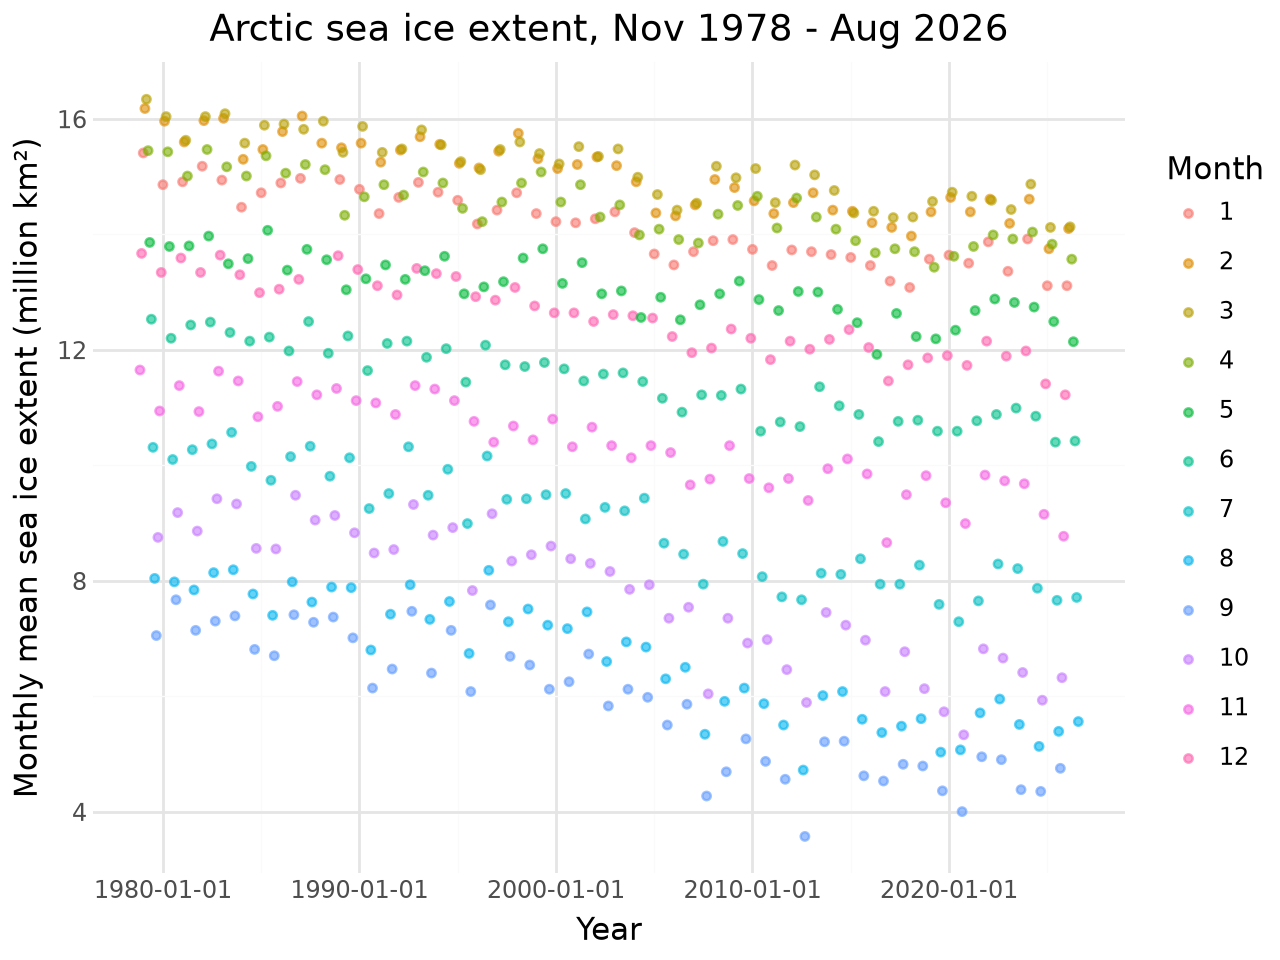

In [11]:
(ggplot(seaice, aes(x="date", y="extent", color="factor(mo)"))
 + geom_point(size=1.2, alpha=0.6)
 + labs(x="Year", y="Monthly mean sea ice extent (million km²)",
        title="Arctic sea ice extent, Nov 1978 - Aug 2026",
        color="Month")
 + theme_minimal())

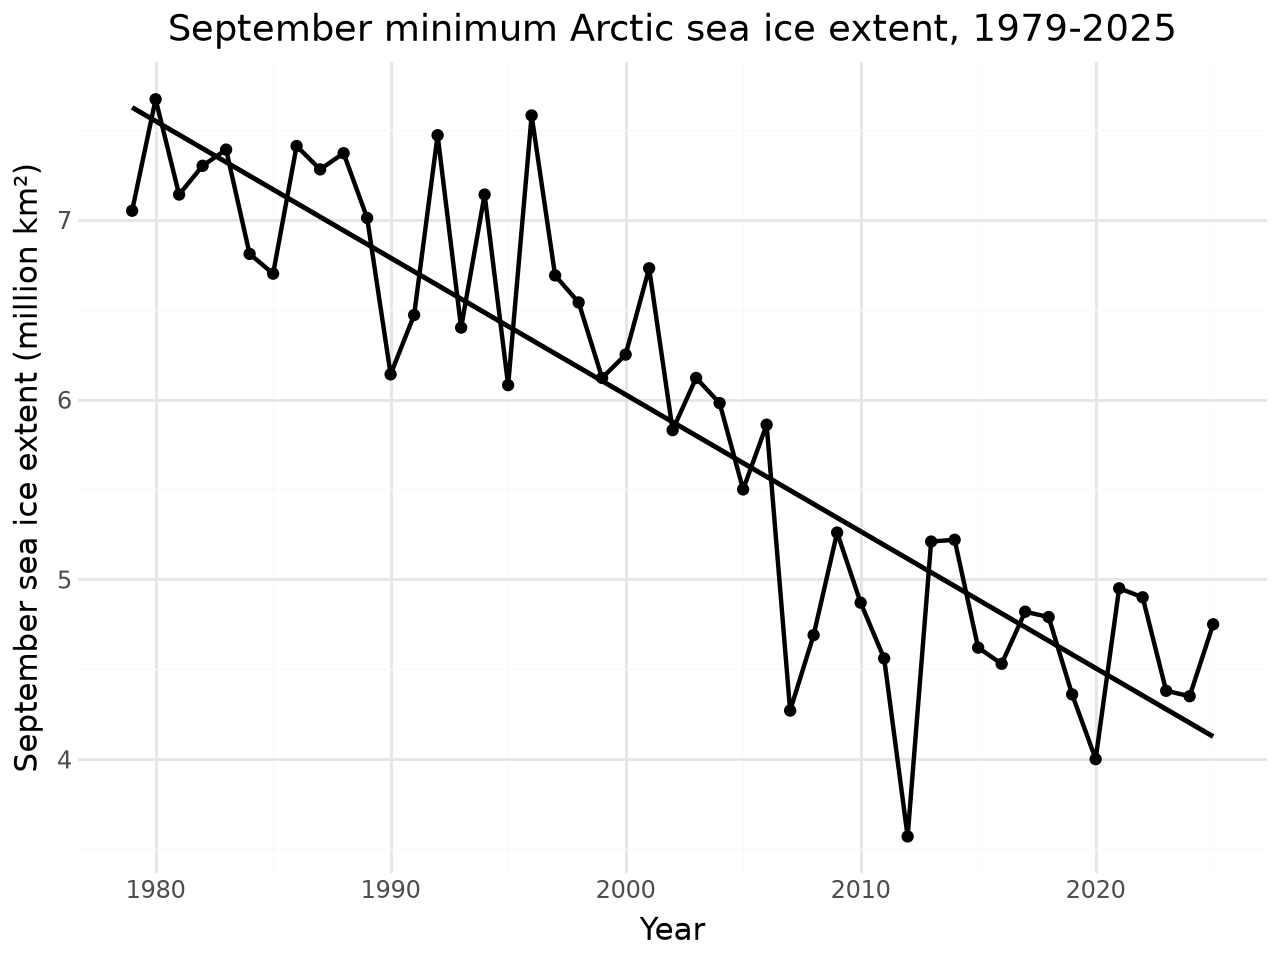

In [12]:
september = seaice[seaice["mo"] == 9]

(ggplot(september, aes(x="year", y="extent"))
 + geom_line(size=0.9)
 + geom_point(size=1.5)
 + geom_smooth(method="lm", se=False)
 + labs(x="Year", y="September sea ice extent (million km²)",
        title="September minimum Arctic sea ice extent, 1979-2025")
 + theme_minimal())

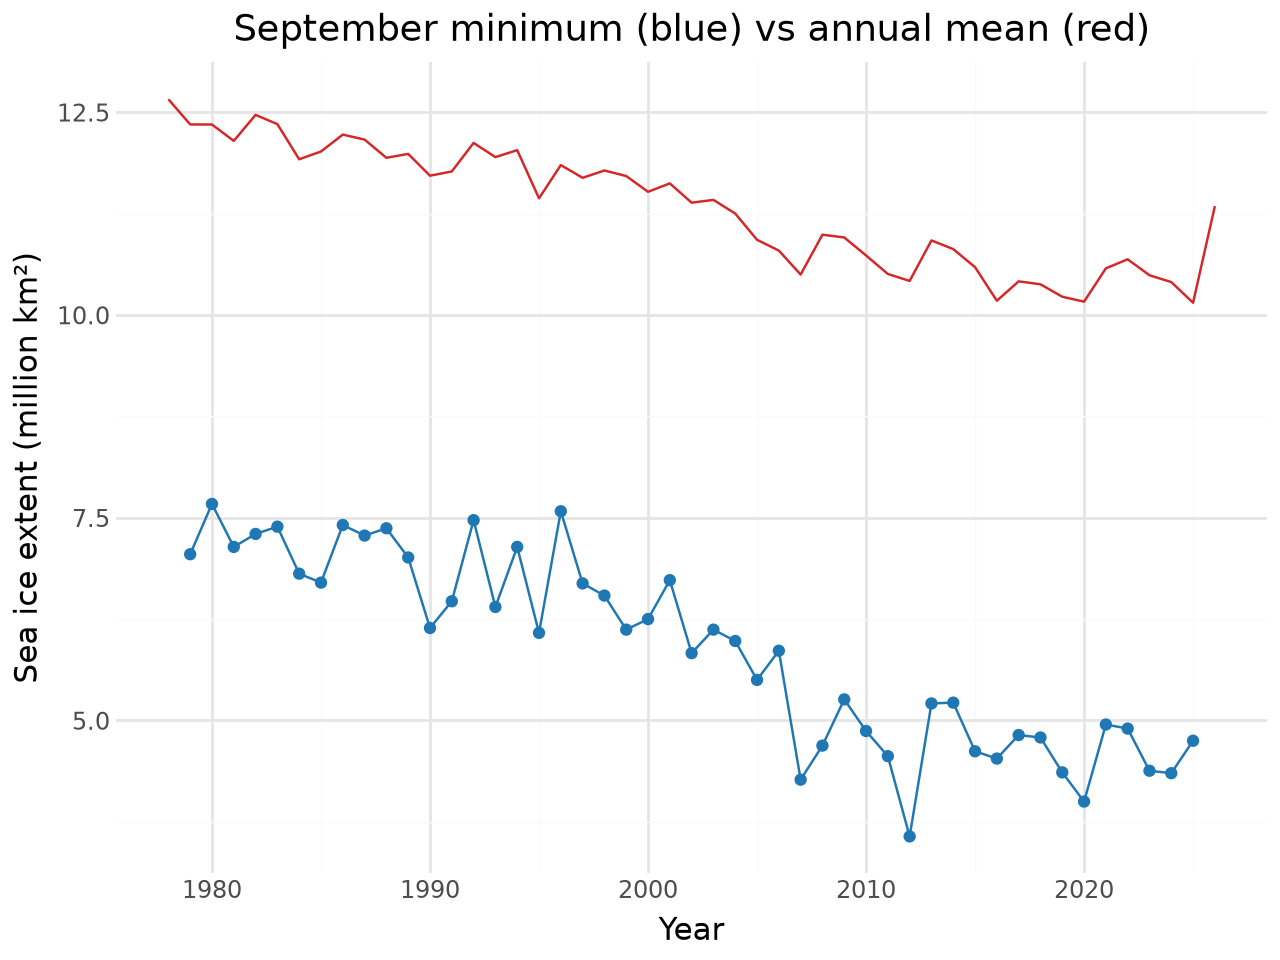

In [13]:
annual_mean = seaice.groupby("year")["extent"].mean().reset_index()

(ggplot()
 + geom_point(aes(x="year", y="extent"), data=september, color="tab:blue")
 + geom_line(aes(x="year", y="extent"), data=september, color="tab:blue")
 + geom_line(aes(x="year", y="extent"), data=annual_mean, color="tab:red")
 + labs(x="Year", y="Sea ice extent (million km²)",
        title="September minimum (blue) vs annual mean (red)")
 + theme_minimal())

**Your answer:** As September is the last month of summer, it is also when Arctic sea ice is lowest and most responsive to accumulated warming. Therefore, it is more accurate to use that as a means to see the sea ice extent rather than annual means, as annual means include winter months where ice is regrowing which could affect the annual means and influence our results.

In [14]:
september.loc[september["year"] == 2025, "extent"]


560    4.75
Name: extent, dtype: float64

In [15]:
september.loc[september["extent"].idxmin()]


year                             2012
mo                                  9
source_dataset             NSIDC-0051
region                              N
extent                           3.57
area                             2.41
date              2012-09-01 00:00:00
Name: 404, dtype: object

### 🔍 Verification block 2

1. Extent: This data measures the extent of sea ice coverage in the northern hemisphere in million km^2, from 1979 to 2026 as of now.
2. Missing data: There isn't any missing data or measurements within the entire file for each month. 
3. Units: Ice extent is measured by million km^2 all throughout the data.
4. Completeness: All monthly files had every year accounted for.
5. Cross-check: Our monthly mean for September 2025 matches with the listed mean of September 2025 in the data. Using code to find the smallest ice extent mean for each measurement taken in September from 1979 to 2025 returns 3.57 million, which is the smallest ice extent value from all the September measurements when examining the data by eye.

---

# Part 3: Emissions by industry

[EXIOBASE](https://www.exiobase.eu/) is a multi-regional, environmentally-extended input-output
database: economic flows between industries and regions worldwide, with the emissions attached to
them. It lets you ask which *industries* drive emissions, not just which countries.

We use the cloud-optimized Parquet copy at
[source.coop/youssef-harby/exiobase-3](https://source.coop/youssef-harby/exiobase-3). The
inter-industry transaction table `Z` for one year:

```
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet
```

### Task 3.1: Ask without guidance

Ask your model to compute total industrial output by origin region for 2022 from that file. Do not
tell it which library to use.

**Record the prompt you used:**

```
[Compute the total industrial output by origin region for 2022 from this file: https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet
]
```

**Which library did it choose, unprompted?**

In [16]:
import ibis

z = ibis.duckdb.connect().read_parquet(
    "https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet",
    table_name="z",
).select("origin_region", "value")

table = (
    z.group_by("origin_region")
    .aggregate(total=z.value.sum() / 1e3)
    .order_by(ibis.desc("total"))
    .execute()
    .rename(columns={"total": "total (bn EUR)"})
)
table["total (bn EUR)"] = table["total (bn EUR)"].map("{:,.1f}".format)

table


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,origin_region,total (bn EUR)
0,CN,"24,399.5"
1,US,"15,870.1"
2,JP,"4,415.3"
3,WA,"4,227.1"
4,DE,"3,262.0"
5,IN,"2,803.6"
6,KR,"2,621.9"
7,WM,"2,592.1"
8,GB,"2,074.9"
9,FR,"2,001.6"


It chose ibis unprompted.

### Task 3.2: Measure what it cost

Run the code it wrote inside the harness below, which reports peak memory and wall time. Your
session has roughly **4 GB of RAM**. Report what happens, including if it does not finish.

In [17]:
import resource, time, contextlib

@contextlib.contextmanager
def measure(label):
    t0 = time.time()
    try:
        yield
    finally:
        peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024**2
        print(f"{label}: peak memory {peak:.2f} GB, elapsed {time.time() - t0:.1f}s")

with measure("ibis"):
    z = ibis.duckdb.connect().read_parquet(
        "https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet",
        table_name="z",
    )
    z.select("origin_region", "value").group_by("origin_region").aggregate(total=z.value.sum()).execute()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ibis: peak memory 0.77 GB, elapsed 22.1s


The code ran for roughly 33 seconds before determining that the peak memory being used was 0.78 GB.

### Task 3.4: Why did it choose that?

Why does a model, asked to analyze data with no further guidance, reach for the library it
reached for? Consider what its training data looks like.

- What does it mean that the tool most likely to be *suggested* is the one most represented in
  code written years ago?
- On the evidence of this exercise, what is the human actually contributing?
- What would have happened if nobody in the room knew the alternative existed?
- In Task 1.5 you found the reverse case. State the rule that covers both, without naming a
  library.

**Your answer:** The model was likely trained to use ibis (or whichever library in a certain situation) when analyzing data similar to that in EXIOBASE. While our model is doing a lot of the work, as a human, we serve to guide our models to handle tasks correctly as we know the full context of what we are trying to achieve in the end, which can involve suggesting alternative methods that work better with what we want to achieve. If no one in the room knew about alternative methods, we'd be stuck with the model's interpretations and views of prompts and tasks, which can differ from what we actually want. A model determines its course of action when given data according to how it was trained to handle data in that format.

---

# Part 4: Which CO2?

The `F_satellite` table holds the environmental extensions — emissions and resource flows attached
to each industry and region.

```
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet
```

### Task 4.1: Survey before you filter

Load the table. Before writing any filter, report how many distinct values the `stressor` column
contains, how many of them mention CO2 (with their units and totals), and how many distinct units
appear in the `unit` column across the whole table.

In [18]:
import ibis

con = ibis.duckdb.connect()
sat = con.read_parquet(
    "https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet",
    table_name="sat",
)

sat.schema()


ibis.Schema {
  stressor  string
  region    string
  sector    string
  value     float64
  unit      string
  year      int64
  format    string
  matrix    string
}

In [19]:
sat.stressor.nunique().execute()

sat.unit.nunique().execute()

sat.select("unit").distinct().execute()

,unit
0,TJ
1,1000 p
2,M.hr
3,M.EUR
4,km2
5,kg
6,kt
7,Mm3


In [20]:
co2 = sat.filter(sat.stressor.like("%CO2%"))

co2.stressor.nunique().execute()

(
    co2.group_by(["stressor", "unit"])
    .aggregate(total=co2.value.sum())
    .order_by(ibis.desc("total"))
    .execute()
)

,stressor,unit,total
0,CO2 - combustion - air,kg,3.132747e+13
1,CO2 - non combustion - Cement production - air,kg,1.662875e+12
2,CO2 - non combustion - Lime production - air,kg,2.536391e+11
3,CO2 - agriculture - peat decay - air,kg,1.750859e+11
4,CO2 - waste - biogenic - air,kg,2.098035e+10
5,CO2 - waste - fossil - air,kg,6.631248e+08


In [21]:
import pandas as pd

co2 = sat.filter(sat.stressor.like("%CO2%"))

pd.DataFrame(
    {
        "metric": ["distinct stressor values", "distinct unit values", "stressors mentioning CO2"],
        "count": [
            sat.stressor.nunique().execute(),
            sat.unit.nunique().execute(),
            co2.stressor.nunique().execute(),
        ],
    }
)

,metric,count
0,distinct stressor values,1025
1,distinct unit values,8
2,stressors mentioning CO2,6


**Your answer:** There are 1025 distinct stressor values, 8 distinct unit values, and 6 stressors that mention CO2.

### Task 4.2: What did you just add together?

Group by region and sum `value` across all stressors. Then look at what that sum contains.

How many different units went into it? Is the result a mass, a volume, a currency, or a number
with no meaning? What is the ratio between the two most common units, and what would mixing them
do to a national total?

In [22]:
import ibis
from IPython.display import display

sat = ibis.duckdb.connect().read_parquet(
    "https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet",
    table_name="sat",
)

naive = (
    sat.group_by("region")
    .aggregate(total=sat.value.sum())
    .order_by(ibis.desc("total"))
    .execute()
)

inside = (
    sat.group_by(["region", "unit"])
    .aggregate(total=sat.value.sum(), rows=sat.count())
    .order_by(["region", ibis.desc("rows")])
    .execute()
)

units = (
    sat.group_by("unit")
    .aggregate(rows=sat.count(), total=sat.value.sum())
    .order_by(ibis.desc("rows"))
    .execute()
)
units["ratio_of_totals_to_2nd_most_common"] = units["total"] / units["total"].iloc[1]
units["ratio_of_rows_to_2nd_most_common"] = units["rows"] / units["rows"].iloc[1]

display(naive, inside, units)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,region,total
0,CN,1.177930e+13
1,US,3.918771e+12
2,IN,2.858126e+12
3,WM,2.211198e+12
4,WA,2.205231e+12
5,RU,1.700051e+12
6,JP,1.081607e+12
7,WL,6.628081e+11
8,KR,6.548995e+11
9,WF,6.208419e+11


,region,unit,total,rows
0,AT,kg,5.067000e+10,12458
1,AT,Mm3,9.084626e+03,2773
2,AT,1000 p,5.475998e+03,1030
3,AT,M.hr,8.802553e+03,1030
4,AT,M.EUR,4.169561e+05,1015
...,...,...,...,...
387,ZA,1000 p,1.809535e+04,854
388,ZA,kt,3.731788e+06,849
389,ZA,M.EUR,3.275456e+05,842
390,ZA,TJ,4.500422e+07,632


,unit,rows,total,ratio_of_totals_to_2nd_most_common,ratio_of_rows_to_2nd_most_common
0,kg,653904,3.489523e+13,240671.835650,3.299263
1,kt,198197,1.449909e+08,1.000000,1.000000
2,Mm3,187647,1.268749e+07,0.087505,0.946770
3,1000 p,47246,6.692388e+06,0.046157,0.238379
4,M.hr,47163,1.476595e+07,0.101840,0.237960
5,M.EUR,45877,8.488405e+07,0.585444,0.231472
6,TJ,36383,4.159443e+09,28.687615,0.183570
7,km2,14841,8.575874e+07,0.591477,0.074880


**Your answer:** 8 different units went into the sums. The sums mean nothing in terms of viability as they are summed from several different units into a single figure. The ratio between the two most common units, kg and kt, and how often they appear in the data, is 3.299. The ratios of their actual total values is 240671.8, which makes sense as kt (kilotons) will yield a much smaller value than kg (kilograms) especially when measuring the same thing. Mixing them would produce another unviable number due to the units being different. 

### Task 4.3: Choose your stressors, and defend the choice

Compute total CO2 emissions by region for 2022.

You must decide which stressors belong in that total. This is a scientific judgment, not a
string-matching exercise: filtering too narrowly omits real emissions, and matching every name
containing `"CO2"` includes flows that standard greenhouse-gas accounting deliberately excludes.
Find out which, and on what grounds.

Ask your model which to include, then check its reasoning against the accounting convention.
Can 
**Which stressors did you include, and why? Which did you exclude, and why?**

### Task 4.4: Reconcile against an independent source

Compare your EXIOBASE national totals against Our World in Data:
<https://github.com/owid/co2-data/raw/master/owid-co2-data.csv>

They will not match. Pick one country and quantify the gap:

| | value | units |
|---|---|---|
| OWID total | | |
| Your EXIOBASE total | | |
| Absolute difference | | |
| Relative difference | | |

Then explain it. The two sources do not measure the same thing — establish what each one actually
counts before you attribute the gap to anything. Candidates to test rather than assert: accounting
scope, gas coverage, sectoral boundaries, your stressor set from 4.3, and year alignment.

**A country that imports most of its manufactured goods should show a particular direction of gap.
Does yours? What does that tell you about the two accounting systems?**

**Your reconciliation:** After asking the model, it chose to include CO2 stressors like combustion, cement/lime production, and fossil carbon in waste. It excluded stressors like biogenic CO2 waste and agriculture/peat decay, as biogenic CO2 waste is considered carbon-neutral, and agricultural CO2 emissions fall under the category of land-use emissions, not energy/industrial emissions. The model adhered to IPCC Guidelines for National Greenhouse Gas Inventories. 

In [23]:
import pandas as pd
import ibis

sat = ibis.duckdb.connect().read_parquet(
    "https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet",
    table_name="sat",
)
included = [
    "CO2 - combustion - air",
    "CO2 - non combustion - Cement production - air",
    "CO2 - non combustion - Lime production - air",
    "CO2 - waste - fossil - air",
]
totals = (
    sat.filter(sat.stressor.isin(included))
    .group_by("region")
    .aggregate(total=sat.value.sum())
    .order_by(ibis.desc("total"))
    .execute()
)
totals["total_Mt"] = totals["total"] / 1e9

owid = pd.read_csv("https://github.com/owid/co2-data/raw/master/owid-co2-data.csv")

def compare(exio_code, owid_iso):
    exio = totals.loc[totals["region"] == exio_code, "total_Mt"].iloc[0]
    owid_mt = owid.loc[(owid["iso_code"] == owid_iso) & (owid["year"] == 2022), "co2"].iloc[0]
    diff = exio - owid_mt
    return pd.DataFrame(
        {
            "value": [owid_mt, exio, diff, diff / owid_mt * 100],
            "units": ["Mt CO2", "Mt CO2", "Mt CO2", "%"],
        },
        index=["OWID total", "Your EXIOBASE total", "Absolute difference", "Relative difference"],
    )

compare("JP", "JPN")

,value,units
OWID total,1029.645000,Mt CO2
Your EXIOBASE total,1051.882381,Mt CO2
Absolute difference,22.237381,Mt CO2
Relative difference,2.159713,%


In [24]:
import pandas as pd
import ibis

sat = ibis.duckdb.connect().read_parquet(
    "https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet",
    table_name="sat",
)
included = [
    "CO2 - combustion - air",
    "CO2 - non combustion - Cement production - air",
    "CO2 - non combustion - Lime production - air",
    "CO2 - waste - fossil - air",
]
totals = (
    sat.filter(sat.stressor.isin(included))
    .group_by("region")
    .aggregate(total=sat.value.sum())
    .order_by(ibis.desc("total"))
    .execute()
)
totals["total_Mt"] = totals["total"] / 1e9

owid = pd.read_csv("https://github.com/owid/co2-data/raw/master/owid-co2-data.csv")

def compare(exio_code, owid_iso):
    exio = totals.loc[totals["region"] == exio_code, "total_Mt"].iloc[0]
    owid_mt = owid.loc[(owid["iso_code"] == owid_iso) & (owid["year"] == 2022), "co2"].iloc[0]
    diff = exio - owid_mt
    return pd.DataFrame(
        {
            "value": [owid_mt, exio, diff, diff / owid_mt * 100],
            "units": ["Mt CO2", "Mt CO2", "Mt CO2", "%"],
        },
        index=["OWID total", "Your EXIOBASE total", "Absolute difference", "Relative difference"],
    )

compare("CN", "CHN")

,value,units
OWID total,11711.808000,Mt CO2
Your EXIOBASE total,11257.073112,Mt CO2
Absolute difference,-454.734888,Mt CO2
Relative difference,-3.882704,%


### 🔍 Verification block 3

1. Extent: Analyzing the parquet file by eye, we can see that it covers stressors from various industries and regions around the world. The data only accounts for the year 2022. This is represented with our code, all the proper units and data was read successfully.
2. Missing data: We have lots of data within the file itself. The full parquet files gives us approximately 2 million rows. My software to view this data only shows me a certain amount of rows without paying an additional fee, but I'm sure that there's enough data to the point where any blank or missing datapoints and measurements can essentially have their influence on our deeper analysis disregarded by the sheer amount of data present. However, I haven't been able to find an example of missing data so far.
3. Units: Many units are being used and considered within this data, covering various aspects such as currency, weight, distance, and volume. These units are all part of relevant calculations and figures related to CO2 stressors, so it makes sense for all of these values to be included in our calculations. However, it's important to know how to use these values and know when these numbers are actually viable. We can not use different units when attempting to sum or find a certain statistic within our data.
4. Completeness: The model generated code which listed 49 regions, 1025 different stressors, and statistics for how often those 8 units appeared in the data. 
5. Cross-check: Comparing our filtered 

---

# Part 5: The hockey stick

Instrumental records cover roughly the last century and a half. To judge whether recent change is
unusual you need a longer baseline, which means proxy records rather than thermometers.

**Vostok ice core**, back roughly 400,000 years:

- Description: <https://cdiac.ess-dive.lbl.gov/trends/co2/vostok.html>
- Data: <https://doi.org/10.3334/CDIAC/ATG.009>

### Task 5.1: Load the ice core record

Load it, and read its documentation carefully enough to say what its index actually is and how it
is sampled. Both bear on what you can legitimately plot next to a modern monthly series.

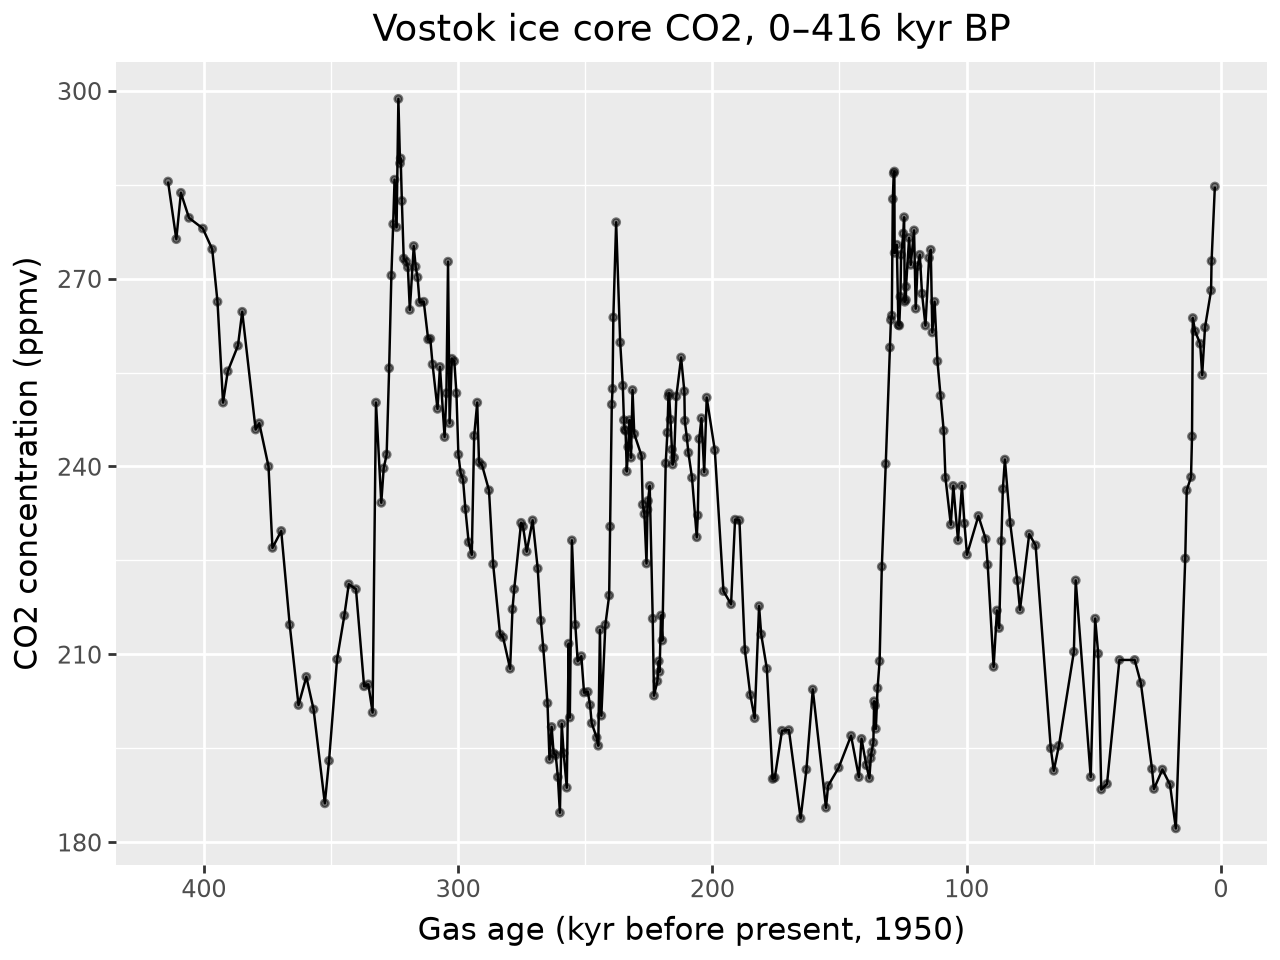

In [25]:
import io
import urllib.request
import pandas as pd
from plotnine import *

url = "https://www.ncei.noaa.gov/pub/data/paleo/icecore/antarctica/vostok/co2nat.txt"
text = (
    urllib.request.urlopen(
        urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    )
    .read()
    .decode("latin-1")
)
lines = text.splitlines()
start = next(
    i for i, line in enumerate(lines) if "Gas age" in line and "CO2 (ppmv)" in line
)
vostok = pd.read_csv(
    io.StringIO("\n".join(lines[start + 1 :])),
    sep=r"\s+",
    names=["gas_age_yr_bp", "co2_ppmv"],
)

vostok["age_kyr_bp"] = vostok["gas_age_yr_bp"] / 1000

(
    ggplot(vostok, aes(x="age_kyr_bp", y="co2_ppmv"))
    + geom_line()
    + geom_point(size=1.0, alpha=0.5)
    + scale_x_reverse()
    + labs(
        x="Gas age (kyr before present, 1950)",
        y="CO2 concentration (ppmv)",
        title="Vostok ice core CO2, 0–416 kyr BP",
    )
)

### Task 5.2: Put modern CO2 in geological context

Combine the Vostok record with the Mauna Loa series from Part 1 in a single figure.

Getting this figure to be *honest* is the hard part:

- The two series have very different sampling resolution. What does a shared axis imply that may
  not be true?
- Where do the records join, and are they measuring the same quantity the same way?
- What does the modern value look like against the full 400,000-year range?

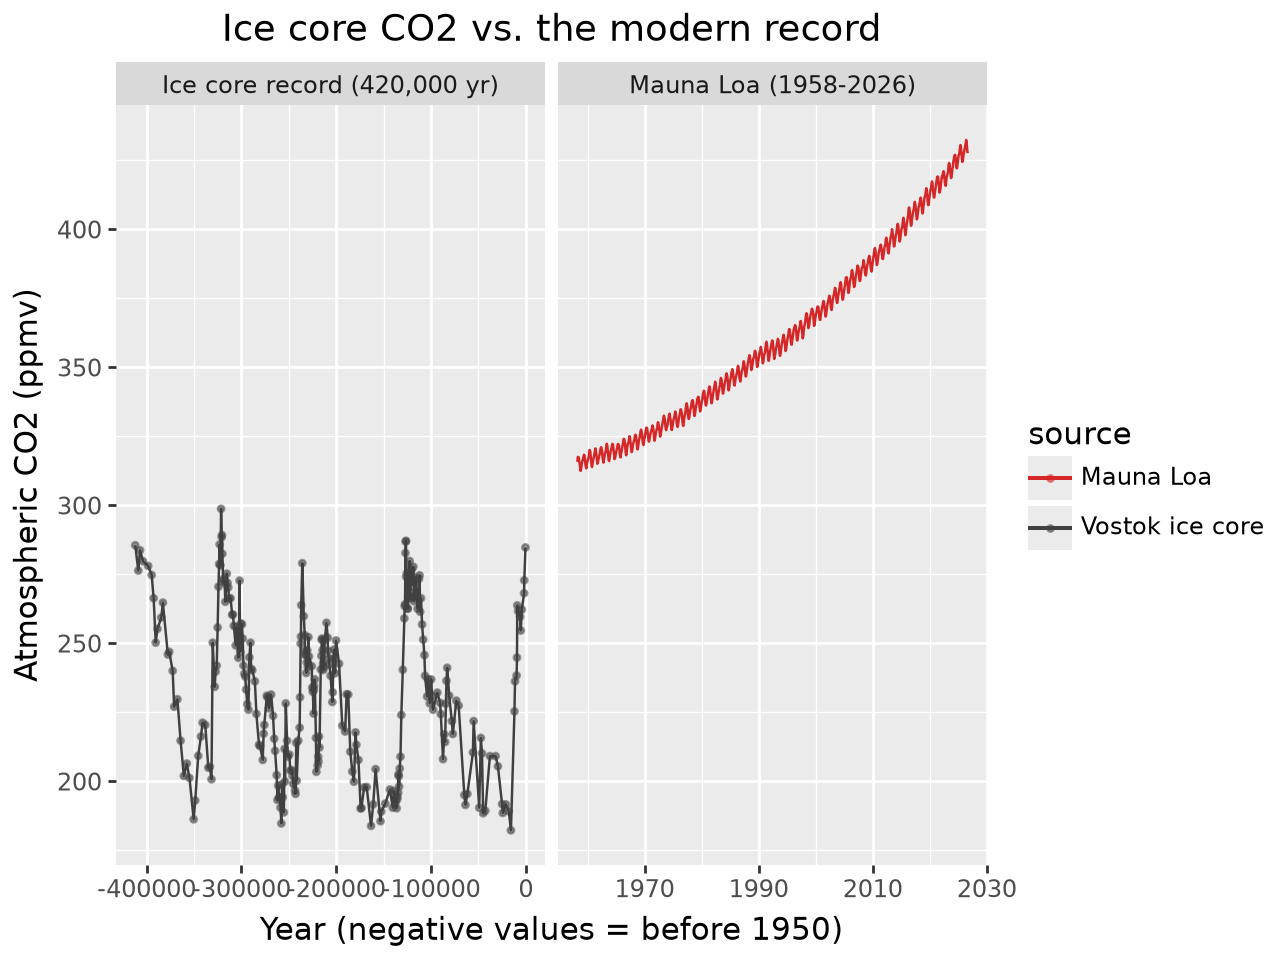

In [26]:
import pandas as pd
from plotnine import *

mlo = df[df["average"] > 0].copy()

history = pd.DataFrame(
    {
        "year": 1950 - vostok["gas_age_yr_bp"],
        "co2_ppmv": vostok["co2_ppmv"],
        "panel": "Ice core record (420,000 yr)",
        "source": "Vostok ice core",
    }
)
modern = pd.DataFrame(
    {
        "year": mlo["decimal_date"],
        "co2_ppmv": mlo["average"],
        "panel": "Mauna Loa (1958-2026)",
        "source": "Mauna Loa",
    }
)
co2_panels = pd.concat([history, modern])
co2_panels["panel"] = pd.Categorical(
    co2_panels["panel"],
    categories=["Ice core record (420,000 yr)", "Mauna Loa (1958-2026)"],
    ordered=True,
)

(
    ggplot(co2_panels, aes(x="year", y="co2_ppmv", color="source"))
    + geom_line()
    + geom_point(data=history, size=0.8, alpha=0.5)
    + facet_wrap("panel", nrow=1, scales="free_x")
    + scale_color_manual(
        values={"Vostok ice core": "#404040", "Mauna Loa": "#d62728"}
    )
    + labs(
        x="Year (negative values = before 1950)",
        y="Atmospheric CO2 (ppmv)",
        title="Ice core CO2 vs. the modern record",
    )
)

Getting a singular "combined" and honest figure was practically impossible. The Mauna Loa data only covers the last 67 years, and when put on the same axis, those 67 years are essentially invisible/hard to actually quantify. Though the record can be joined on time, plotting both sets of data on one axis makes the Mauna Loa data hard to visualize, as the Vostok ice record tracks back 400,000 years. However, when plotting side by side on separate time axes, we find that we can see general overall patterns for however far back the data sampled goes. We can see an overeall consistent atmospheric CO2 level in the Vostok ice core record with fluctuations between ~200 and 300 ppmv, while we see a gradual increase from ~310 ppmv to ~430 ppmv for the Mauna Loa data, albeit on a much smaller timescale than that of the Vostok ice record.

### Task 5.3: Interpret

Relative to [Mann et al (1998)](https://doi.org/10.1038/33859):

- Does your reconstruction support the paper's central claim?
- Where does it differ, and why — more recent data, different proxies, different processing?
- What in your figure is a genuine finding, and what is an artifact of a choice you made?

**Your interpretation:** My reconstruction does somewhat support the paper's central claim, with some stipulations. Even though the paper focuses on global increases in temperature, our data regarding CO2 levels could support the idea of global temperatures increasing. When looking at the Mauna Loa data, we can see a consistent increase it atmospheric CO2 vs when compared to the Vostok ice record and its atmospheric CO2 levels. However, the Vostok ice record is sampled over many more years, and perhaps the 67 years covered in the Mauna Loa data makes it difficult to truly compare the two due to the vast difference in time scales. Both methods of sampling between the ice record and Mauna Loa were also different, with the Vostok ice record data being collected through an analysis of air trapped in a deep ice core, and the Mauna Loa data being sourced from atmospheric data. While the data in my figure is all genuine, I chose to have the axes separated for adequate visualization. This could lead to the atmospheric CO2 increase in the Mauna Loa data to look more extreme, but I chose to visualize them in that way, as combining axes would essentially make the Mauna Loa data hard to actually see in the scale beyond a sliver.

---

# Part 6: Reflection

1. **Failure inventory.** List every case where the model produced code that ran without error but
   was wrong. What was wrong, and what tipped you off?
2. **Detection.** Which of those would you have caught from the plot alone? Which required going
   back to the source documentation?
3. **Division of labor.** What did you contribute that the model did not? If the answer for some
   task is "nothing", say so.
4. **Plan mode.** Where did approving the plan catch something? Where was it just friction?
5. **Tool choice.** You have now seen the same task done two ways, and data read locally versus
   streamed. What decides which is right, and who makes that decision?

**Your reflection:**

1. A lot of the times, the visualizations I attempted to create with the model didn't appropriately visualize the data, occasionally using bad scales to plot data or creating inappropriate visualizations/plots instead of just organizing data into a chart. These were easy to spot by eye, but occasionally I'd run into an issue where I thought a visualization was adequate for a certain task, but not adequate for a later task that built off the same visualization.
2. A lot of the time, the plots were totally nonsensical for lack of a better term. Data would be visualized in a counter-intuitive manner. In situations where I considered these plots to be invalid, any shortcomings with the visualizations also made themselves apparent when I attempted to answer tasks using those invalid visualizations and realized that they incorrectly generated or just weren't useful for the context of the task.
3. The model did all the heavy lifitng in terms of writing code to generate charts and visualizations to support my answers, which were hand-written by me. Often times, I'd have to help orient the model to generate an accurate/correct data visualization according to my standards. Some tasks required more input from me than others, while others could be fully answered through the code provided by the model.
4. I found more success using the "Ask" mode overall. The plan mode was more aimed at setting me up to answer the question without actually answering it, while the "Ask" mode made it easier to implement stipulations and other things I wanted to note/include in visualizations. The "Ask" mode is just more user-friendly in my opinion, especially for those with little to no coding experience.
5. At the end of the day, the choice for which tool to use comes down to the user, as they must decide which is more appropriate in a certain situation. Perhaps the plan mode is more appropriate for those with more extensive coding experience and knowledge, as they are more able to implement their own knowledge alongside suggestions from the model. The "Ask" mode is much more user friendly, but makes us trust the model's methods of visualizations and representing data and limits our input.

---

## Submission

- [ ] Notebook runs top to bottom without errors
- [ ] All three verification blocks completed
- [ ] Prompts recorded where asked (Tasks 2.1, 3.1)
- [ ] Memory and timing table filled in (Task 3.3)
- [ ] Stressor selection defended (Task 4.3) and reconciliation quantified (Task 4.4)
- [ ] Hockey stick figure with the modern record in geological context (Task 5.2)
- [ ] Reflection complete (Part 6)
- [ ] README updated with team members, badge, and description
- [ ] Repository passes its GitHub Actions check

See [rubric.md](rubric.md) for scoring.